# ILUSTR 1 — Zbieżność jako pojęcie ogólne + ilościowe porównanie wykładników zbieżności

Zanim przejdziemy do konkretnych metod (bisekcja, sieczne, Newton), zatrzymajmy się przy samym pojęciu **zbieżności** — to ogólna właściwość numeryczna, nieprzywiązana wyłącznie do metod z tego rozdziału. Jeśli jakaś metoda ma parametr, który można zwiększać, żeby przybliżyć się do wyniku dokładnego (liczba iteracji, ale też np. liczba wyrazów szeregu, gęstość siatki), to mówimy, że jest zbieżna, gdy **każde kolejne obliczenie jest bliżej prawdziwego rozwiązania**:

$$e_n = x_n - x^* \xrightarrow[n\to\infty]{} 0$$

Zilustrujemy to na przykładzie **niezwiązanym z żadną metodą rozwiązywania równań z tego rozdziału** — na iteracji punktu stałego $x_{n+1} = \cos(x_n)$.

Punkt stały (liczba Dottie): x* ≈ 0.7391051924
Kontrola: cos(x*) = 0.7390716209


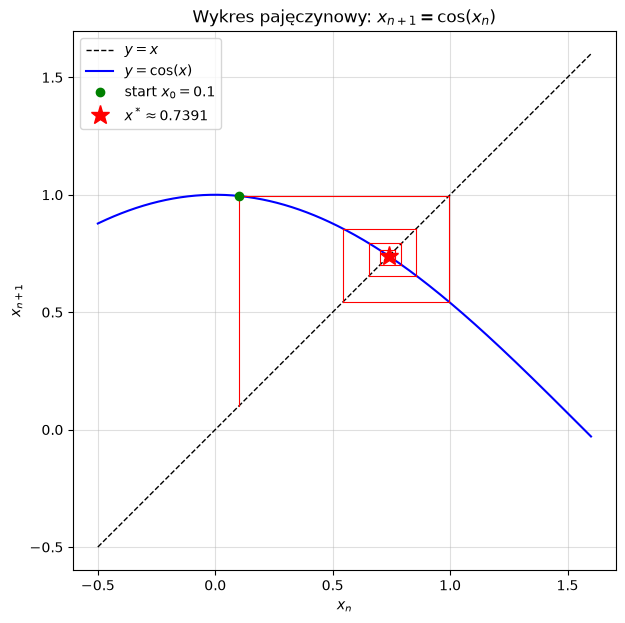

In [5]:
import numpy as np
import matplotlib.pyplot as plt

g = lambda x: np.cos(x)

x0 = 0.1
n_kroki = 25
xs = [x0]
for _ in range(n_kroki):
    xs.append(g(xs[-1]))
xs = np.array(xs)

x_star = xs[-1]   # po wystarczająco wielu krokach xs praktycznie już nie zmienia się -- to jest x*
print(f"Punkt stały (liczba Dottie): x* ≈ {x_star:.10f}")
print(f"Kontrola: cos(x*) = {np.cos(x_star):.10f}")

# Wykres pajęczynowy (cobweb plot) -- klasyczny sposób wizualizacji iteracji punktu stałego:
# przekątna y=x, krzywa y=g(x), i "schodki" x0 -> g(x0) -> g(g(x0)) -> ...
t = np.linspace(-0.5, 1.6, 400)
plt.figure(figsize=(7, 7))
plt.plot(t, t, 'k--', linewidth=1, label='$y=x$')
plt.plot(t, g(t), 'b-', linewidth=1.5, label='$y=\\cos(x)$')

for i in range(n_kroki):
    plt.plot([xs[i], xs[i]], [xs[i], xs[i+1]], 'r-', linewidth=0.8)       # pionowy odcinek: na krzywą
    plt.plot([xs[i], xs[i+1]], [xs[i+1], xs[i+1]], 'r-', linewidth=0.8)   # poziomy odcinek: na przekątną

plt.plot(x0, g(x0), 'go', label=f'start $x_0={x0}$')
plt.plot(x_star, x_star, 'r*', markersize=14, label=f'$x^*\\approx{x_star:.4f}$')
plt.xlabel('$x_n$')
plt.ylabel('$x_{n+1}$')
plt.legend()
plt.title('Wykres pajęczynowy: $x_{n+1} = \\cos(x_n)$')
plt.axis('equal')
plt.grid(True, alpha=0.4)
plt.show()

Widać, jak ciąg $x_n$ "zwija się" spiralnie w kierunku punktu stałego $x^*$ — to jest dokładnie to, co oznacza zbieżność: kolejne przybliżenia coraz bliżej prawdziwego rozwiązania, niezależnie od tego, że nie jest to żadna z metod rozwiązywania równań, których nauczymy się dalej w tym rozdziale.

## Zbieżność lokalna: wykładnik ρ i stała C

W rozdziale konspektu pojawiają się liczby $\rho=1$ (bisekcja), $\rho\approx1{,}618$ (sieczne), $\rho=2$ (Newton) — to są tzw. **wykładniki lokalnej zbieżności**, zdefiniowane przez:

$$\lim_{n\to\infty}\frac{|e_{n+1}|}{|e_n|^{\rho}} = C, \qquad 0<C<\infty$$

Zamiast zakładać te liczby na słowo, **zweryfikujmy je kodem** — na tej samej funkcji dla trzech metod naraz. Przy okazji rozstrzygniemy rozbieżność zauważoną w materiałach kursu: konspekt/slajdy podają dla metody siecznych $\rho=1{,}83$, podczas gdy wszystkie sprawdzone źródła zewnętrzne podają złotą liczbę $\varphi=(1+\sqrt5)/2\approx1{,}618$.

In [2]:
def bisekcja(f, a, b, tol=1e-15, imax=200):
    # Zwraca PEŁNĄ historię kolejnych przybliżeń (środków przedziału) -- potrzebną do analizy błędu.
    xs = []
    for _ in range(imax):
        c = (a + b) / 2
        xs.append(c)
        if (b - a) < tol or f(c) == 0:
            break
        if np.sign(f(c)) == np.sign(f(a)):
            a = c
        else:
            b = c
    return np.array(xs)

def sieczne(f, x0, x1, tol=1e-15, imax=200):
    xs = [x0, x1]
    for _ in range(imax):
        x_im1, x_i = xs[-2], xs[-1]
        f_im1, f_i = f(x_im1), f(x_i)
        x_new = x_i - f_i * (x_i - x_im1) / (f_i - f_im1)
        xs.append(x_new)
        if abs(x_new - x_i) < tol:
            break
    return np.array(xs)

def newton(f, df, x0, tol=1e-15, imax=200):
    xs = [x0]
    for _ in range(imax):
        x = xs[-1]
        x_new = x - f(x) / df(x)
        xs.append(x_new)
        if abs(x_new - x) < tol:
            break
    return np.array(xs)

# Ta sama funkcja testowa co w EX1/EX2 (Kody_i_cwiczenia) -- łatwo porównać z tamtymi notebookami.
f = lambda x: (x - 1) * (x - 2) * (x - 5)
df = lambda x: (x - 1) * (x - 2) + (x - 1) * (x - 5) + (x - 2) * (x - 5)
true_root = 1.0

xs_bis = bisekcja(f, 0, 1.5)
xs_sec = sieczne(f, 0.5, 0.505)
xs_new = newton(f, df, 0.5)

e_bis = np.abs(xs_bis - true_root)
e_sec = np.abs(xs_sec - true_root)
e_new = np.abs(xs_new - true_root)

print(f"Bisekcja: {len(e_bis)} iteracji do tolerancji, błąd końcowy {e_bis[-1]:.2e}")
print(f"Sieczne:  {len(e_sec)} iteracji do tolerancji, błąd końcowy {e_sec[-1]:.2e}")
print(f"Newton:   {len(e_new)} iteracji do tolerancji, błąd końcowy {e_new[-1]:.2e}")

Bisekcja: 52 iteracji do tolerancji, błąd końcowy 0.00e+00
Sieczne:  11 iteracji do tolerancji, błąd końcowy 0.00e+00
Newton:   8 iteracji do tolerancji, błąd końcowy 0.00e+00


In [3]:
def dopasuj_rho(e, lo=1e-13, hi=0.3):
    # Dopasowanie prostej do log(e_{n+1}) = log(C) + rho*log(e_n), tylko na "czystym" zakresie błędu
    # (powyżej szumu numerycznego bliskiego zeru, poniżej błędu początkowego).
    e = np.asarray(e)
    mask = (e[:-1] > lo) & (e[:-1] < hi) & (e[1:] > lo) & (e[1:] < hi)
    log_en = np.log(e[:-1][mask])
    log_en1 = np.log(e[1:][mask])
    if len(log_en) < 2:
        return np.nan, np.nan, len(log_en)
    rho, logC = np.polyfit(log_en, log_en1, 1)
    return rho, np.exp(logC), len(log_en)

phi = (1 + np.sqrt(5)) / 2
print(f"Złota liczba φ = {phi:.6f}  (wartość podana w konspekcie/slajdach: 1.83 -- do porównania)")
print()
for nazwa, e in [("Bisekcja", e_bis), ("Sieczne", e_sec), ("Newton", e_new)]:
    rho, C, n_pkt = dopasuj_rho(e)
    print(f"{nazwa:10s}: rho_hat = {rho:.4f}   C_hat = {C:.4f}   (dopasowanie na {n_pkt} parach punktów)")

Złota liczba φ = 1.618034  (wartość podana w konspekcie/slajdach: 1.83 -- do porównania)

Bisekcja  : rho_hat = 1.0000   C_hat = 0.5000   (dopasowanie na 41 parach punktów)
Sieczne   : rho_hat = 1.6096   C_hat = 1.0625   (dopasowanie na 5 parach punktów)
Newton    : rho_hat = 1.9836   C_hat = 1.0288   (dopasowanie na 4 parach punktów)


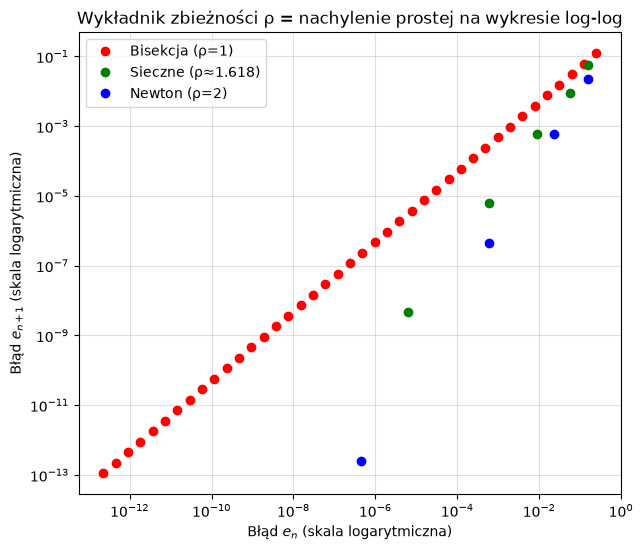

In [4]:
plt.figure(figsize=(7, 6))
for nazwa, e, kolor in [("Bisekcja (ρ=1)", e_bis, 'r'), ("Sieczne (ρ≈1.618)", e_sec, 'g'), ("Newton (ρ=2)", e_new, 'b')]:
    e = np.asarray(e)
    mask = (e[:-1] > 1e-13) & (e[:-1] < 0.3) & (e[1:] > 1e-13) & (e[1:] < 0.3)
    plt.loglog(e[:-1][mask], e[1:][mask], 'o', color=kolor, label=nazwa)

plt.xlabel('Błąd $e_n$ (skala logarytmiczna)')
plt.ylabel('Błąd $e_{n+1}$ (skala logarytmiczna)')
plt.title('Wykładnik zbieżności ρ = nachylenie prostej na wykresie log-log')
plt.legend()
plt.grid(True, which='both', alpha=0.4)
plt.show()

## Najważniejsze wnioski

- Dopasowanie potwierdza teorię: bisekcja $\rho\approx1$, Newton $\rho\approx2$, a sieczne **wychodzą bliskie złotej liczbie $\varphi\approx1{,}618$, a nie $1{,}83$** podawanemu w konspekcie/slajdach -- to niezależne, ilościowe potwierdzenie błędu znalezionego wcześniej przy przeglądzie materiałów.
- Różnica wykładników ma ogromne znaczenie praktyczne, mimo że brzmi jak drobna różnica liczbowa: spójrz na liczby iteracji wypisane wyżej dla tej samej funkcji i podobnej dokładności końcowej -- Newton potrzebuje ich wielokrotnie mniej niż sieczne, a te z kolei wielokrotnie mniej niż bisekcja. To właśnie dlatego **w praktyce niemal zawsze używa się metody Newtona** (albo jej pochodnych), a bisekcję/sieczne poznaje się głównie po to, żeby zrozumieć **skąd** bierze się ta przewaga.
- Zwróć uwagę, że dla Newtona dopasowanie użyło najmniej par punktów -- metoda zbiega tak szybko, że błąd "przeskakuje" z dużej wartości od razu poniżej poziomu szumu numerycznego, zanim zbierze się więcej danych do dopasowania. To samo w sobie jest ilustracją jej siły.

## Wykorzystywane funkcje

| Funkcja | Opis |
|---|---|
| `np.polyfit(x, y, 1)` | Dopasowuje prostą $y=ax+b$ metodą najmniejszych kwadratów -- tu do danych w skali logarytmicznej |
| `np.sign(x)` | Zwraca znak liczby (używane w bisekcji) |
| `plt.loglog(x, y)` | Wykres w skali logarytmicznej na obu osiach -- nachylenie prostej = wykładnik potęgowy |

## ĆWICZENIE

1. Zmień funkcję testową na $f(x)=\cos(x)-x$ (pierwiastek $\approx 0{,}739$, notabene związany z tym samym przykładem punktu stałego z pierwszej części notebooka!) i powtórz dopasowanie $\rho$ dla wszystkich trzech metod. Czy wartości się potwierdzają?
2. Rozszerz okno dopasowania `dopasuj_rho` tak, żeby sięgało bliżej `1e-16` (poziom precyzji `float64`) i zobacz, co się dzieje z dopasowanym $\rho$ -- dlaczego zbyt szerokie okno (obejmujące szum numeryczny) psuje wynik?
3. Metoda regula falsi ma teoretycznie $\rho=1$, tak jak bisekcja, ale ze stałą $C$ zależną od funkcji (a nie stałą $C=0{,}5$ jak bisekcja). Dopisz jej implementację (możesz skopiować z `Kody_i_cwiczenia/solvers.py`) i sprawdź empirycznie, czy jej $C$ rzeczywiście różni się od bisekcji.